# Analisis y predicción de Ventas Parte 5.

In [ ]:
# Primero conectamos con Google Drive (Si esque estamos trabajando en Google Colab).
from google.colab import drive
drive.mount('/content/drive')

In [11]:
# Importamos librerias.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Continuar desde la Parte IV.
- Asegúrate de tener el DataFrame df ya cargado y preparado desde la Parte IV.

In [12]:
# Importamos los datos exportados desde la parte IV.
# Carga el archivo retail_sales_edit.csv en un DataFrame de Pandas.
path = "../data/retail_sales_dataset_edit.csv"
df = pd.read_csv(path)
# Muestra las primeras 10 filas del DataFrame para confirmar que los datos se han cargado correctamente.
df.head(10)

,Unnamed: 0,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,TA Normalized,Q Normalized,Type of Sale,TA Desv
0,0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,0.666667,Mid,-0.154937
1,1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,0.333333,Mid,0.275443
2,2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,0.000000,Low,-0.215696
3,3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,0.240506,0.000000,Low,0.022278
4,4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,0.037975,0.333333,Mid,-0.180253
5,5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,0.002532,0.000000,Low,-0.215696
6,6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,0.012658,0.333333,Mid,-0.205570
7,7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,0.037975,1.000000,High,-0.180253
8,8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,0.291139,0.333333,Mid,0.072911
9,9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,0.088608,1.000000,High,-0.129620


# Exploración de Datos Avanzada.
- Realiza un análisis de correlación y crea un mapa de calor para visualizar las relaciones entre las variables.

In [13]:
# Para este ejemplo, primero removeremos las columnas Unnamed y ID.
df = df.drop(["Unnamed: 0", "Transaction ID"], axis=1)
df.head(3)

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,TA Normalized,Q Normalized,Type of Sale,TA Desv
0,2023-11-24,CUST001,Male,34,Beauty,3,50,150,0.063291,0.666667,Mid,-0.154937
1,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,0.493671,0.333333,Mid,0.275443
2,2023-01-13,CUST003,Male,50,Electronics,1,30,30,0.002532,0.000000,Low,-0.215696


In [14]:
# Calculamos la correlación de Pearson utilizando solo las columnas númericas.
correlation_matrix = df.corr(method="pearson", numeric_only=True)
print("Correlación de Pearson:n", correlation_matrix)

Correlación de Pearson:n                      Age  Quantity  Price per Unit  Total Amount  \
Age             1.000000 -0.023737       -0.038423     -0.060568   
Quantity       -0.023737  1.000000        0.017501      0.373707   
Price per Unit -0.038423  0.017501        1.000000      0.851925   
Total Amount   -0.060568  0.373707        0.851925      1.000000   
TA Normalized  -0.060568  0.373707        0.851925      1.000000   
Q Normalized   -0.023737  1.000000        0.017501      0.373707   
TA Desv        -0.060568  0.373707        0.851925      1.000000   

                TA Normalized  Q Normalized   TA Desv  
Age                 -0.060568     -0.023737 -0.060568  
Quantity             0.373707      1.000000  0.373707  
Price per Unit       0.851925      0.017501  0.851925  
Total Amount         1.000000      0.373707  1.000000  
TA Normalized        1.000000      0.373707  1.000000  
Q Normalized         0.373707      1.000000  0.373707  
TA Desv              1.000000      0.3

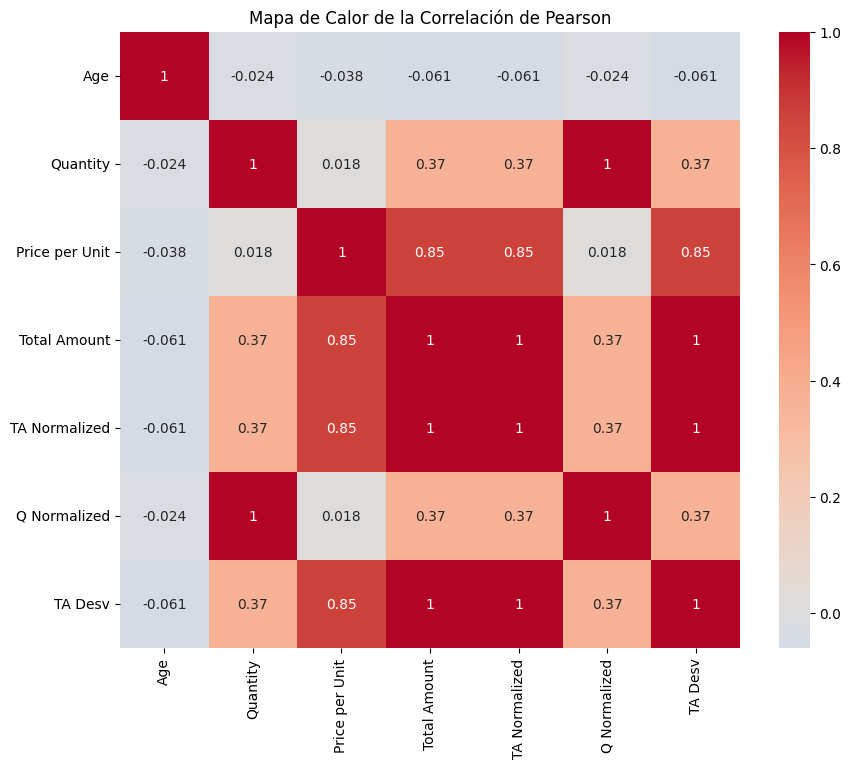

In [15]:
# Creamos un mapa de calor para la matriz de correlación de Pearson.
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Mapa de Calor de la Correlación de Pearson")
plt.show()

Para el analisis podemos ignorar todos los 1 de la linea vertical ya que es la relación de cada variable consigo misma.

Lo que podemos observar y que si es relevante:
- La relación de la edad y ventas no parece tener relación, es decir la edad no influye de alguna forma en las ventas registradas.

Fuera de eso no se puede hacer un mayor análisis sin más datos, debido a las pocas columnas númericas que tenemos además de precio unitario y precio total o cantidad. No podemos extraer mayor información. Y añadir al análisis que una cantidad de venta mayor significa un mayor precio seria indicar lo evidente.

- Crea subplots para comparar diferentes variables clave.
- Añade cuadrículas, leyendas, anotaciones y flechas a tus gráficos para mejorar la claridad y la información.

In [28]:
# Configuramos primeo un estilo.
sns.set_style("whitegrid") # Estilo de seaborn

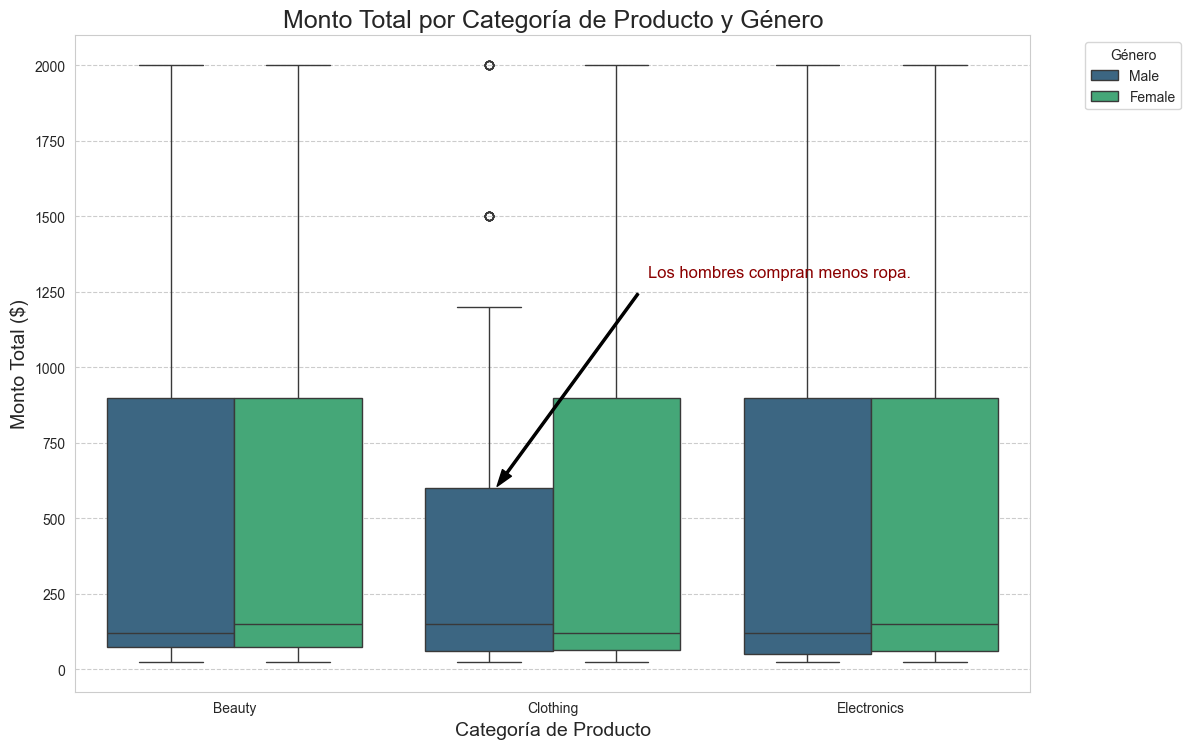

In [60]:
# Creamos un Gráfico de Boxplot. De Monto Total por Categoría de Producto diferenciado por Género.
plt.figure(figsize=(12, 8))
sns.boxplot(x="Product Category", y="Total Amount", hue="Gender", data=df, palette="viridis")
plt.title("Monto Total por Categoría de Producto y Género", fontsize=18)
plt.xlabel("Categoría de Producto", fontsize=14)
plt.ylabel("Monto Total ($)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=1)
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc="upper left")

x_coord_clothing_male = 1 - 0.2
y_coord_clothing_male = 570

# Añadimos una anotación simple.
plt.annotate("Los hombres compran menos ropa.",
             xy=(x_coord_clothing_male, y_coord_clothing_male),
             xytext=(x_coord_clothing_male + 0.5, 1300),
             arrowprops=dict(facecolor="black", edgecolor="black", shrink=0.05, width=1.5, headwidth=8),
             fontsize=12,
             color="darkred")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En este análisis podemos observar que las compras entre hombres y mujeres están prácticamente igualadas en todo sentido.

Y que los hombres no gustan demasiado de comprar en la categoría de Ropa.

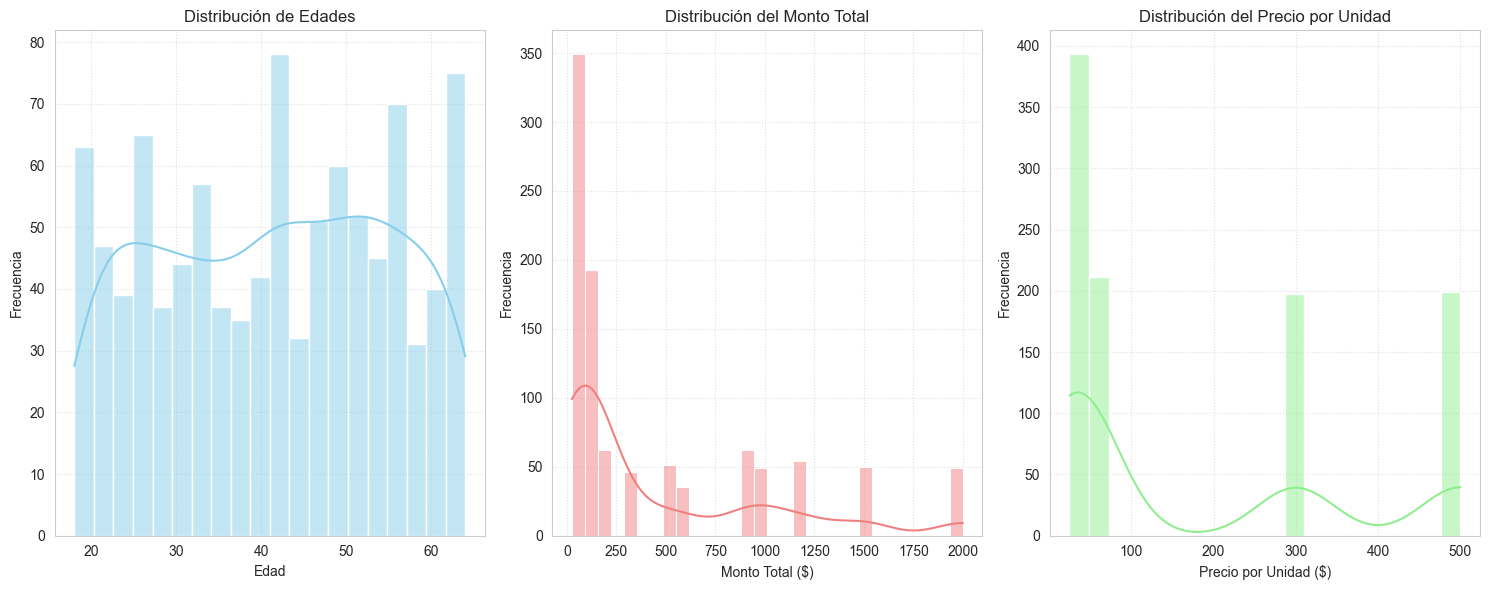

In [61]:
# Distribuciones de Variables.
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.histplot(df["Age"], kde=True, bins=20, color="skyblue")
plt.title("Distribución de Edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle=":", alpha=0.6)

plt.subplot(1, 3, 2)
sns.histplot(df["Total Amount"], kde=True, bins=30, color="lightcoral")
plt.title("Distribución del Monto Total")
plt.xlabel("Monto Total ($)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle=":", alpha=0.6)

plt.subplot(1, 3, 3)
sns.histplot(df["Price per Unit"], kde=True, bins=20, color="lightgreen")
plt.title("Distribución del Precio por Unidad")
plt.xlabel("Precio por Unidad ($)")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

Aqui lo más significativo que podemos observar es:
1. La distribución de edad es suficientemente equitativa, se mantiene un buen alcance de la población de toda edad.
2. La relación entre precio unitario y monto total es correlativa.

No solamente en el sentido de que si un precio sube el monto total también. Sino que al haber más productos a menor precio, la gente hace más compras con un bajo precio.

Se terminan agrupando las ventas en montos bajos, por lo que podría ser un buen enfoque el apuntar a mayor cantida de productos a costo reducido, o hacer versiones más económicas de todos los productos.